# Analysis: How the Dashboard Helps Airbnb Owners Optimize Pricing and Identify High-Value Areas

Our dashboard is designed to help Airbnb owners make data-driven decisions by identifying high-potential neighborhoods with strong revenue opportunities and low competition. Here’s how each visualization contributes:

### Visualize Listing Density on a Map
The map shows the number of listings per neighborhood. Owners can quickly see which areas are saturated and which have fewer competitors, helping them target neighborhoods with growth potential.

### Explore Price Ranges via Box Plots
Once an area of interest is identified on the map, owners can use box plots to examine the price distribution for each room type in that neighborhood. This helps determine optimal pricing and avoid overpricing or underpricing their listings.

### Revenue vs Occupancy Rate Scatter Plot
By plotting estimated revenue against listing count, owners can identify neighborhoods in the top-right quadrant, areas with high revenue and strong demand. Users can also visualise the competition thru the bubble size.

### Highlight High-Value Neighborhoods on a Map
High-potential neighborhoods are then identified thru filtering out neighbourhoods that have high competiton and visualized on a map, making it easy to understand their geographic location.

### Room Type Distribution in High-Value Areas
A bar chart shows the distribution of room types in the highlighted neighborhoods. Owners can identify which room types perform best in each area and tailor their listings to gain a competitive advantage.

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import requests
import json
from urllib.request import urlopen
import warnings 
warnings.filterwarnings('ignore')

colorblind_palette = ["#E69F00", "#56B4E9", "#009E73",
                      "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

In [28]:
df = pd.read_csv('airbnb_price_cleaned.csv')
df.head(3)

,neighbourhood_group,neighbourhood,lat,long,instant_bookable,cancellation_policy,room_type,construction_year,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,occupancy_rate,estimated_occupied_nights,estimated_revenue,log_price
0,Brooklyn,Kensington,40.64749,-73.97237,False,strict,Private room,2020.0,966,10,9.0,2021-10-19,0.21,4.0,6.0,286.0,0.216438,79.0,76314.0,6.873164
1,Manhattan,Midtown,40.75362,-73.98377,False,moderate,Entire home/apt,2007.0,142,30,45.0,2022-05-21,0.38,4.0,2.0,228.0,0.375342,137.0,19454.0,4.955827
2,Manhattan,Harlem,40.80902,-73.94190,True,flexible,Private room,2005.0,620,3,0.0,NaN,NaN,5.0,1.0,352.0,0.035616,13.0,8060.0,6.429719


# Lisitng count for each neighbourhood by room type

In [29]:
from ipywidgets import interact, Dropdown
import plotly.express as px
import requests


#_____________________MAP_______________________________
agg_room = (
    df.groupby(["neighbourhood", "room_type"])["price"]  # or "price" just to count
    .count()
    .reset_index()
    .rename(columns={"price": "listing_count", "neighbourhood": "name"})
)

geojson = requests.get(
    "https://gist.githubusercontent.com/ix4/ff7603f48283cf06fc4fb3dfb6a0635c/raw/3eae4056c9d4de99f0040b6bedbd9ba547e8d215/nyc.geojson"
).json()

for i, feature in enumerate(geojson["features"]):
    feature["id"] = str(i) 

name_to_id = {
    feature["properties"]["neighborhood"]: feature["id"]
    for feature in geojson["features"]
}

fixes = {
    "Hell's Kitchen": "Clinton",
    "Hell’s Kitchen": "Clinton",
    "Kips Bay": "Kips Bay",
    "Murray Hill": "Murray Hill",
    "Gramercy": "Gramercy",
    "Flatiron": "Flatiron District",
    "NoMad": "NoMad",
    "Civic Center": "Civic Center",
    "Two Bridges": "Two Bridges",
}
agg_room["id"] = agg_room["name"].replace(fixes).map(name_to_id)
agg_room = agg_room.dropna(subset=["id"])

#_________________________________________________________________

# Assuming agg_room and geojson are already prepared

room_types = agg_room['room_type'].unique().tolist()

def show_roomtype_map(room_type):
    df_rt = agg_room[agg_room['room_type'] == room_type]
    
    fig = px.choropleth_mapbox(
        df_rt,
        geojson=geojson,
        locations="id",
        color="listing_count",
        hover_name="name",
        color_continuous_scale="Plasma",
        mapbox_style="open-street-map",
        zoom=10,
        center={"lat": 40.7128, "lon": -73.96},
        opacity=0.8,
        labels={"listing_count": "Number of Listings"},
        title=f"NYC Airbnb Listings Count — {room_type}"
    )

    fig.update_traces(marker_line_color="black", marker_line_width=1.5)
    fig.update_layout(margin=dict(l=0,r=0,t=60,b=0), height=700)
    fig.show()

interact(show_roomtype_map, room_type=Dropdown(options=room_types, value=room_types[0], description='Room Type:'))

interactive(children=(Dropdown(description='Room Type:', options=('Entire home/apt', 'Private room', 'Shared r…

<function __main__.show_roomtype_map(room_type)>

- On this map, the density of listings in each area is represented by color. 
- Using the dropdown, hosts can select different room types to see their distribution across areas. 
- This allows hosts to visualize popular versus underserved areas. Additionally, when hovering over a location, hosts can see the exact number of listings present in that area, helping them make informed decisions about where to list their property.

# Price range for each room type for each neighbourhood

In [30]:
from ipywidgets import interact, Dropdown
import plotly.express as px
colors = px.colors.qualitative.Plotly

def show_neighborhood_prices(neighbourhood):
    if neighbourhood == 'All Neighborhoods':
        df_filtered = df
        title = "All NYC Neighbourhoods - Price by Room Type"
    else:
        df_filtered = df[df['neighbourhood'] == neighbourhood]
        title = f"{neighbourhood} - Price by Room Type"
    
    fig = go.Figure()
    
    for i, rt in enumerate(room_types):
        df_rt = df_filtered[df_filtered['room_type'] == rt]
        fig.add_trace(
            go.Box(
                y=df_rt['price'],
                name=rt,
                marker_color=colorblind_palette[i % len(colorblind_palette)],
                boxmean=True
            )
        )
    
    fig.update_layout(
        title=title,
        yaxis_title="Price ($)",
        xaxis_title="Room Type",
        height=500
    )
    
    fig.show()


neighborhoods = ['All Neighborhoods'] + sorted(df['neighbourhood'].unique().tolist())
interact(show_neighborhood_prices, neighbourhood=Dropdown(options=neighborhoods, value='All Neighborhoods'))

interactive(children=(Dropdown(description='neighbourhood', options=('All Neighborhoods', 'Allerton', 'Arden H…

<function __main__.show_neighborhood_prices(neighbourhood)>

- From the dropdown, hosts can choose the interested neighbourhood and check the price range for all room types in the area.  
- This could help hosts set an ideal price range, preventing under or overpricing their lisitngs.  
- Hosts can use the median price as a guide to price their listing similarly to others in the area. For more premium listings, they can consider pricing closer to the third quartile (Q3), while for budget-friendly options, they can price near the first quartile (Q1). This approach allows hosts to strategically position their listings based on market demand and target audience.

# High revenue + High demand neighbourhoods

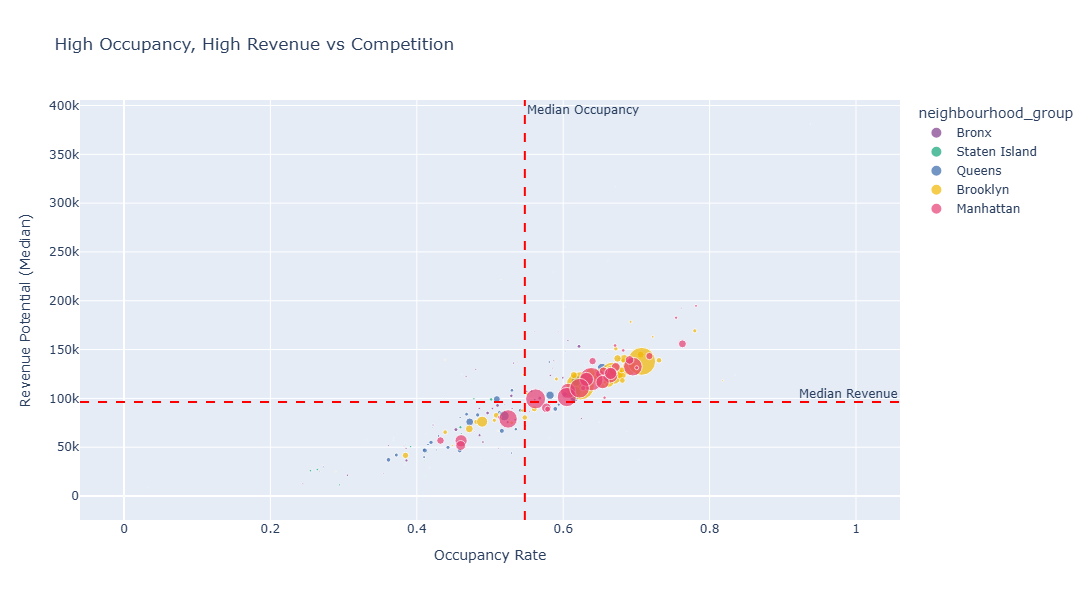

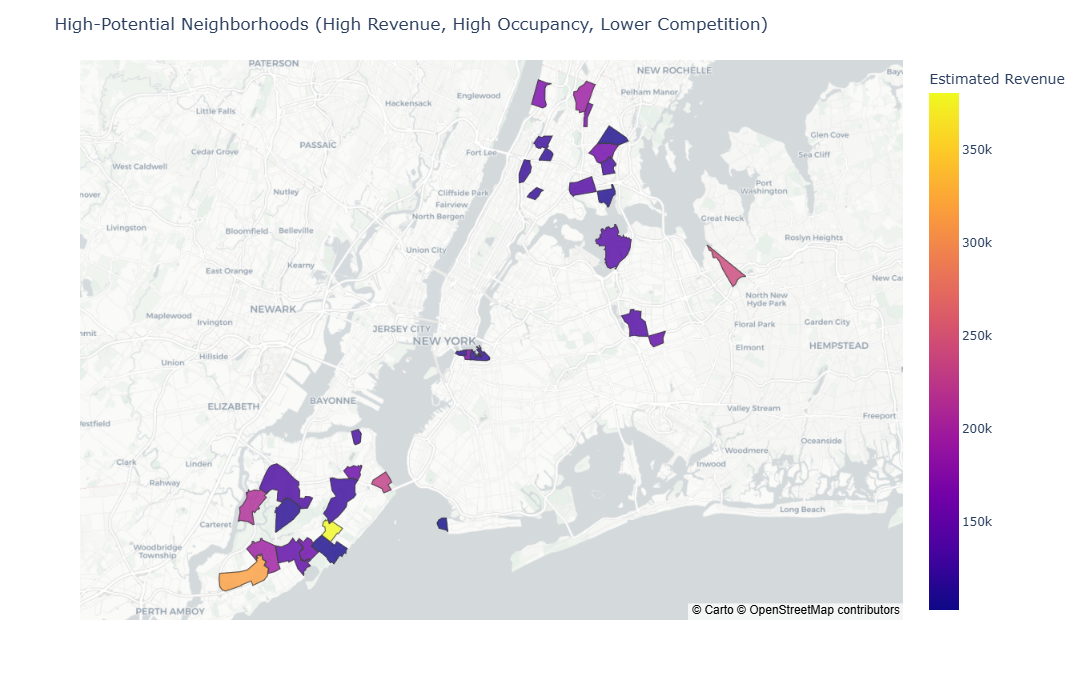

In [40]:
neighborhood_analysis = df.groupby('neighbourhood').agg({
    'price': 'median',
    'occupancy_rate': 'mean',
    'neighbourhood': 'count',
    'estimated_revenue': 'median',
    'number_of_reviews': 'mean',
    'neighbourhood_group': 'first'
}).rename(columns={'neighbourhood': 'listing_count'})

neighborhood_analysis['revenue_per_listing'] = (
    neighborhood_analysis['estimated_revenue'] / neighborhood_analysis['listing_count']
)

fig = px.scatter(
    neighborhood_analysis.reset_index(),
    x='occupancy_rate',          # x = demand
    y='estimated_revenue',       # y = revenue
    size='listing_count',        # bubble = competition
    color='neighbourhood_group',
    color_discrete_sequence=px.colors.qualitative.Bold,
    hover_name='neighbourhood',
    hover_data=['price', 'occupancy_rate', 'listing_count'],
    title='High Occupancy, High Revenue vs Competition',
    labels={
        'listing_count': 'Competition (Number of Listings)',
        'estimated_revenue': 'Revenue Potential (Median)',
        'price': 'Median Price',
        'occupancy_rate': 'Occupancy Rate'
    }
)

median_occupancy = neighborhood_analysis['occupancy_rate'].median()
median_revenue = neighborhood_analysis['estimated_revenue'].median()

fig.add_hline(
    y=median_revenue,
    line_dash="dash", line_color="red",
    annotation_text="Median Revenue"
)
fig.add_vline(
    x=median_occupancy,
    line_dash="dash", line_color="red",
    annotation_text="Median Occupancy"
)

fig.update_layout(height=600)
fig.show()


high_potential = neighborhood_analysis[
    (neighborhood_analysis['occupancy_rate'] > median_occupancy) &
    (neighborhood_analysis['estimated_revenue'] > median_revenue)
].copy()

median_competition = neighborhood_analysis['listing_count'].median()
high_potential = high_potential[
    high_potential['listing_count'] < median_competition
].copy()

import json
import requests
import plotly.express as px

geojson = requests.get(
    "https://gist.githubusercontent.com/ix4/ff7603f48283cf06fc4fb3dfb6a0635c/raw/3eae4056c9d4de99f0040b6bedbd9ba547e8d215/nyc.geojson"
).json()

for i, feature in enumerate(geojson["features"]):
    feature["id"] = str(i)

name_to_id = {
    feature["properties"]["neighborhood"]: feature["id"]
    for feature in geojson["features"]
}

high_potential["id"] = high_potential.index.map(name_to_id)

fig_map = px.choropleth_mapbox(
    high_potential,
    geojson=geojson,
    locations="id",
    color="estimated_revenue",
    hover_name=high_potential.index,
    hover_data={
        "listing_count": True,
        "estimated_revenue": True,
        "occupancy_rate": True
    },
    color_continuous_scale="plasma",
    mapbox_style="carto-positron",
    zoom=9.5,
    center={"lat": 40.7128, "lon": -73.96},
    opacity=0.8,
    labels={"estimated_revenue": "Estimated Revenue"}
)

fig_map.update_layout(
    height=700,
    title_text="High-Potential Neighborhoods (High Revenue, High Occupancy, Lower Competition)"
)
fig_map.show()
high_potential_neighborhoods = list(high_potential.index)


In [38]:
print("High-potential neighborhoods:")
for i,n in enumerate(high_potential_neighborhoods):
    print(i,"-", n)

High-potential neighborhoods:
0 - Arden Heights
1 - Bay Terrace, Staten Island
2 - Bull's Head
3 - Castle Hill
4 - Chelsea, Staten Island
5 - College Point
6 - DUMBO
7 - Great Kills
8 - Grymes Hill
9 - Highbridge
10 - Jamaica Hills
11 - Kew Gardens Hills
12 - Little Neck
13 - Melrose
14 - Morris Park
15 - Mount Hope
16 - Navy Yard
17 - New Brighton
18 - New Dorp
19 - New Springville
20 - Oakwood
21 - Olinville
22 - Pelham Gardens
23 - Riverdale
24 - Sea Gate
25 - Shore Acres
26 - Soundview
27 - Todt Hill
28 - University Heights
29 - Vinegar Hill
30 - Westchester Square
31 - Woodlawn
32 - Woodrow


- From the scatter plot of revenue against occupancy rate , we can identify star neighbourhoods with high revenue potential and have strong demand. The revenue potential is calculated as a proxy:
- Revenue Potential= Occupancy of a listing 365 * Price
- We identify the high potential neighbourhoods by filtering out the nes with strong competition and plot on a map, allowing hosts to easily visualize and identify areas with high earning opportunities.

# Room type distribution for each star neighbourhood 

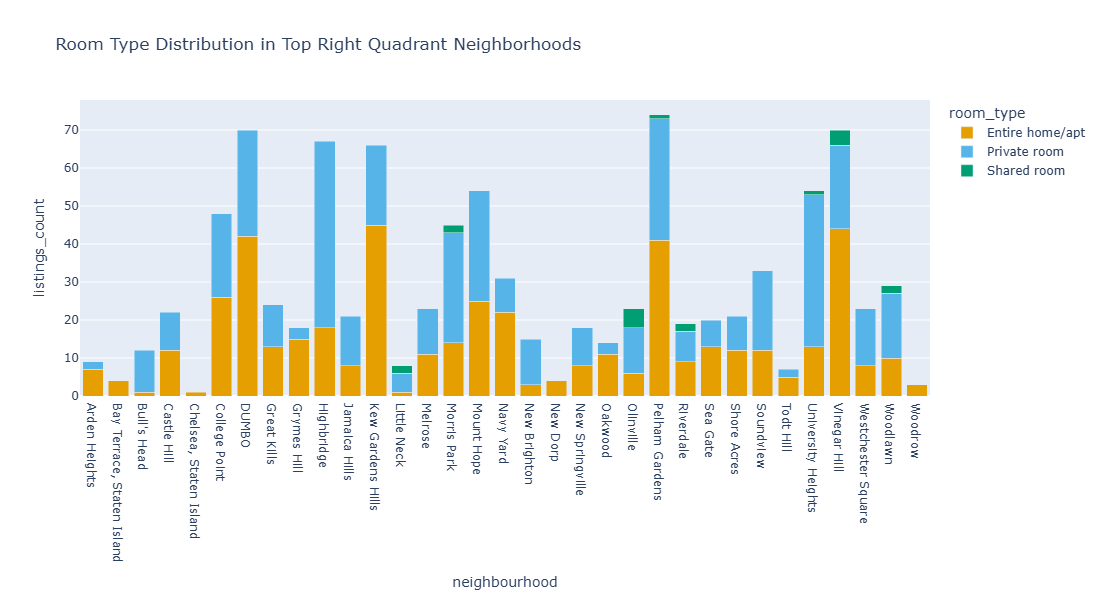

In [33]:
top_right_rooms = df[df['neighbourhood'].isin(high_potential.index)]

room_summary = (
    top_right_rooms.groupby(['neighbourhood', 'room_type'])
    .agg(
        listings_count=('price', 'count'),
        avg_price=('price', 'mean'),
    )
    .reset_index()
)

fig = px.bar(
    room_summary,
    x='neighbourhood',
    y='listings_count',
    color='room_type',
    color_discrete_sequence=colorblind_palette,
    title='Room Type Distribution in Top Right Quadrant Neighborhoods',
)
fig.update_layout(barmode='stack', height=600)
fig.show()


- In this bar chart, hosts can visualise the room type distribution for the star neighbourhoods.
- On hover, hosts can see the count for each room type.
- Hosts can use this to tailor their listings, like provide private room lisitngs in area that only have entire home lisitngs etc


## User work flow 
- For general usage: Hosts can first explore listing density using the listing saturation choropleth map. Once they identify an area of interest, they can select it from the dropdown below to view the price range for that area.

- For new hosts: They can start by visualizing the top potential areas (identified from the scatter plot) on the choropleth map. Next, they can understand the market in that area through the room type distribution bar chart, and finally explore the price range using the box plots.